# Week 9 Phase 2.1R-E — how early can the width signal be read?

**Phase 2.1R showed the useful width number is almost always found in the first few percent of the trace. So: is an opening slice enough, and how short can it be?**

This notebook reads the generated artifacts. The engine is `src/week9_phase2_1re_early_prefix_width_control.py`.


In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
pd.set_option('display.width', 190)
pd.set_option('display.max_columns', 40)
ROOT = Path.cwd().parents[1] if Path.cwd().name == 'week_09' else Path.cwd()
OUT = ROOT / 'outputs' / 'week9_phase2_1re_early_prefix_width_control'
assert OUT.is_dir(), OUT


## 1. Why this follow-up exists

Phase 2.1R found that the largest width jump helps the model **rank** Keyhole risk, and that **95.4%** of those largest jumps happen in the first 5% of the trace.

Put those together and the question is obvious: **if the signal is all at the start, do we need the rest of the trace?**

So we rebuild exactly the same feature, but only allow the model to watch an opening slice — 2%, 5%, 10%, 20%, 40% or 100% of the analysis points — and see what changes.


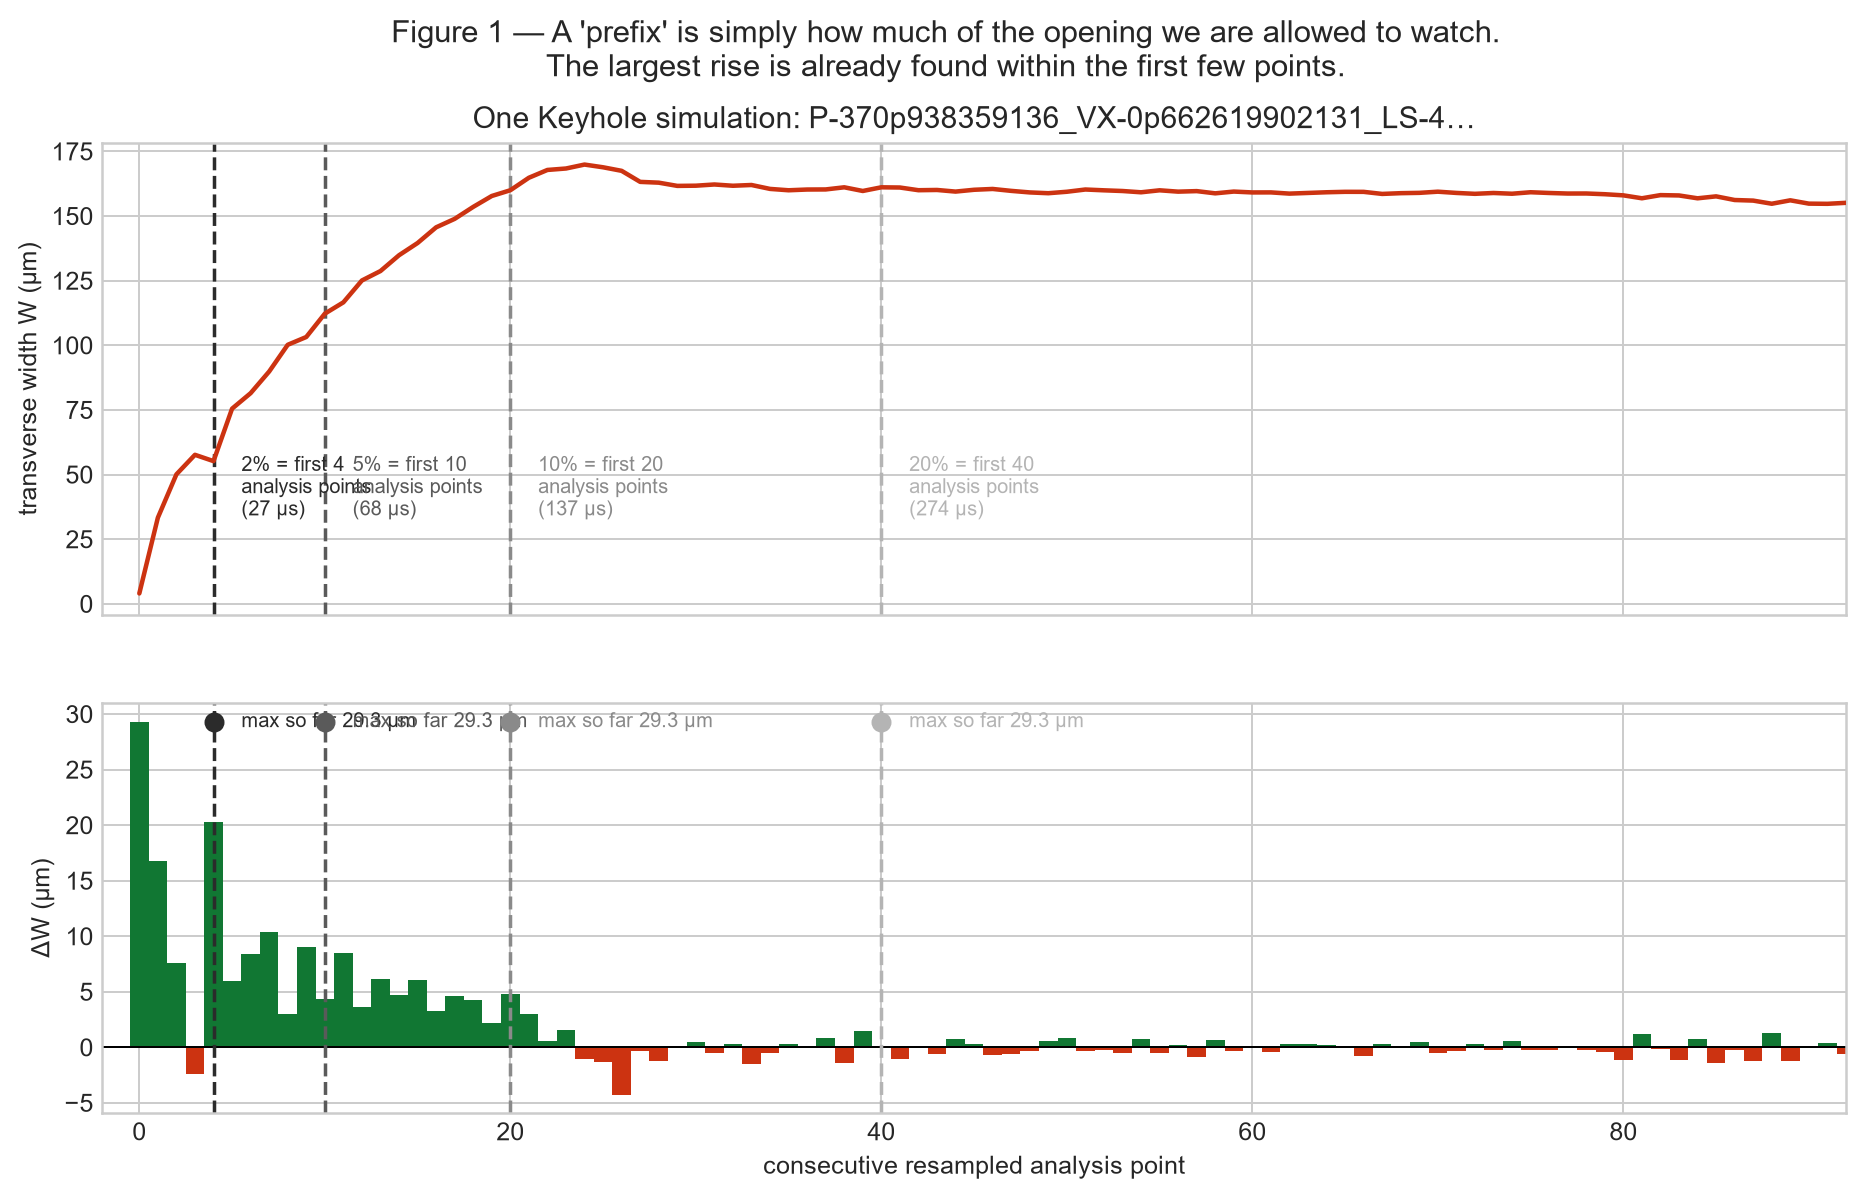

In [2]:
display(Image(filename=OUT/'figures'/'01_what_a_prefix_means.png'))


## 2. What a prefix feature is, concretely

Suppose a simulation's opening widths are 4, 31, 52, 56, 63 µm. The changes between neighbouring analysis points are `[+27, +21, +4, +7]`.

* Allowed to watch **only the first five analysis points**, we record the biggest rise we have seen: `max_positive_delta_W = 27`.
* Allowed the **whole trace**, we might find something bigger later.

The whole phase is measuring how often we actually do find something bigger later, and what it costs us when we stop early.

**No peeking.** The feature at prefix *p* uses only transitions ending at or before analysis point `ceil(p × 200)`. The audit below recomputes every value a second, independent way and reports the latest analysis point it consulted.


In [3]:
display(pd.read_csv(OUT/'prefix_no_future_audit.csv'))


,prefix_fraction,transitions_allowed,latest_analysis_point_used,no_future_point_used,max_abs_difference_vs_independent_recompute,median_observed_window_ms,median_observed_window_us,status
0,0.02,4,4,True,0.0,0.027366,27.365684,PASS
1,0.05,10,10,True,0.0,0.068414,68.414210,PASS
2,0.10,20,20,True,0.0,0.136828,136.828420,PASS
3,0.20,40,40,True,0.0,0.273657,273.656840,PASS
4,0.40,80,80,True,0.0,0.547314,547.313680,PASS
5,1.00,200,200,True,0.0,1.368284,1368.284200,PASS


## 3. Does a short opening already contain the full-trace number?

This is the cheapest possible check and it decides most of the phase. For each prefix we ask what fraction of simulations already have *exactly* the number they would have got from the whole trace.


,prefix_fraction,transitions_used,median_observed_window_us,pearson_r_with_full_trace,spearman_r_with_full_trace,fraction_already_equal_to_full,median_shortfall_um,median_ratio_to_full
0,0.02,4,27.3657,0.9797,0.9881,0.9114,0.0,1.0
1,0.05,10,68.4142,0.9937,0.9933,0.9543,0.0,1.0
2,0.10,20,136.8284,0.9975,0.9992,0.9971,0.0,1.0
3,0.20,40,273.6568,0.9999,0.9998,0.9971,0.0,1.0
4,0.40,80,547.3137,1.0000,1.0000,1.0000,0.0,1.0
5,1.00,200,1368.2842,1.0000,1.0000,1.0000,0.0,1.0


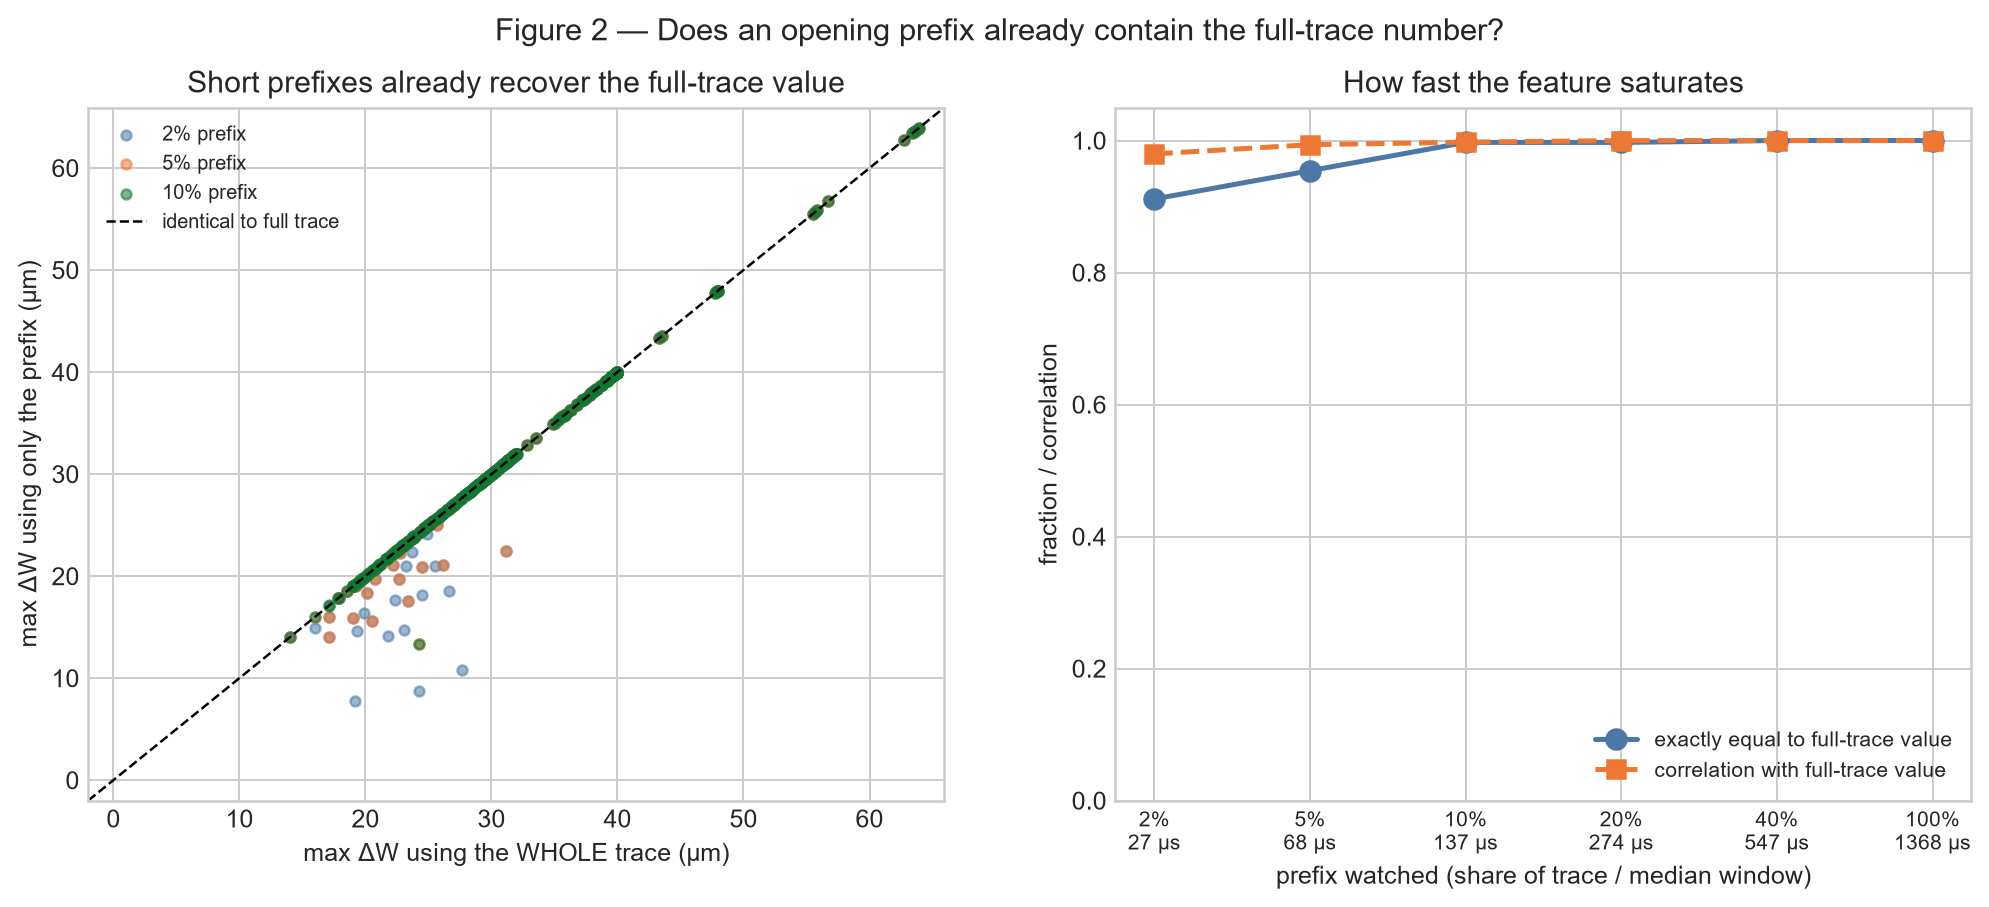

In [4]:
display(pd.read_csv(OUT/'prefix_saturation_profile.csv').round(4))
display(Image(filename=OUT/'figures'/'02_prefix_vs_full_feature.png'))


## 4. Separation at each prefix

Keyhole simulations widen **more slowly** at the start — the effect is negative at every window tested, which is the same inverted direction Phase 2.1R found.


,prefix_fraction,feature,median_observed_window_us,conduction_median,keyhole_median,median_difference_keyhole_minus_conduction,median_difference_ci_low,median_difference_ci_high,cliffs_delta,roc_auc_whole_sample,pr_auc_whole_sample
0,0.02,max_positive_delta_W_p02,27.3657,29.7830,29.2747,-0.5083,-2.8340,0.7242,-0.2000,0.4000,0.1685
1,0.05,max_positive_delta_W_p05,68.4142,29.7830,29.2747,-0.5083,-2.7790,0.7146,-0.2030,0.3985,0.1682
2,0.10,max_positive_delta_W_p10,136.8284,29.8192,29.2747,-0.5445,-2.8333,0.6833,-0.2023,0.3988,0.1681
3,0.20,max_positive_delta_W_p20,273.6568,29.8192,29.2747,-0.5445,-2.9155,0.6612,-0.2036,0.3982,0.1680
4,0.40,max_positive_delta_W_p40,547.3137,29.8192,29.2747,-0.5445,-2.8363,0.6496,-0.2042,0.3979,0.1680
5,1.00,max_positive_delta_W_p100,1368.2842,29.8192,29.2747,-0.5445,-2.7952,0.6663,-0.2042,0.3979,0.1680


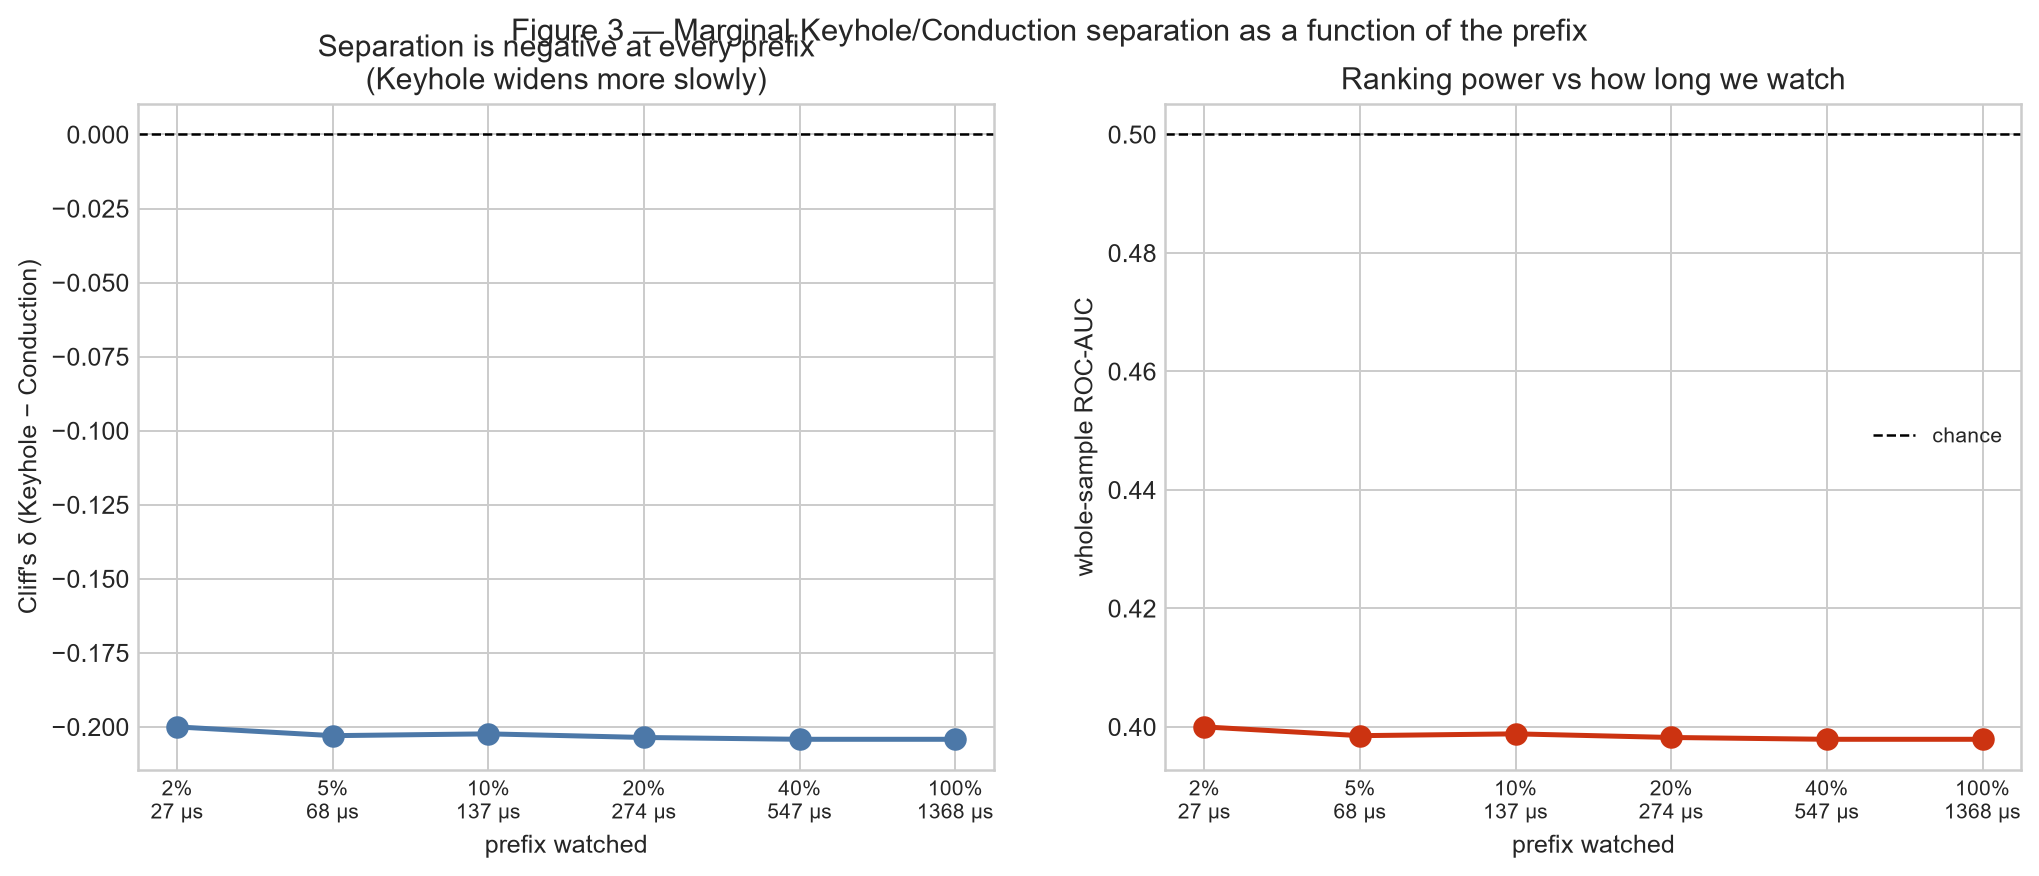

In [5]:
display(pd.read_csv(OUT/'prefix_univariate_separation.csv').round(4))
display(Image(filename=OUT/'figures'/'03_separation_vs_prefix.png'))


## 5. The simple threshold rule, at each prefix

Same leak-free rule as Phase 2.1R: inside each fold the cut **and its direction** are learned from the training simulations only, then frozen and applied to the held-out ones.


,prefix_fraction,subset,learned_threshold_median,fraction_of_folds_choosing_below,balanced_accuracy_mean,balanced_accuracy_sd_across_repeats,keyhole_recall_mean,total_false_negative,total_false_positive
0,0.02,full,32.408,1.0,0.6239,0.0083,0.9218,110,3775
1,0.02,q20,32.408,1.0,0.5643,0.0247,0.8661,79,683
2,0.02,q30,32.408,1.0,0.5714,0.0190,0.8795,89,1089
3,0.05,full,32.408,1.0,0.6239,0.0083,0.9218,110,3775
4,0.05,q20,32.408,1.0,0.5643,0.0247,0.8661,79,683
5,0.05,q30,32.408,1.0,0.5714,0.0190,0.8795,89,1089
6,0.10,full,32.408,1.0,0.6239,0.0083,0.9218,110,3775
7,0.10,q20,32.408,1.0,0.5643,0.0247,0.8661,79,683
8,0.10,q30,32.408,1.0,0.5714,0.0190,0.8795,89,1089
9,0.20,full,32.408,1.0,0.6239,0.0083,0.9218,110,3775


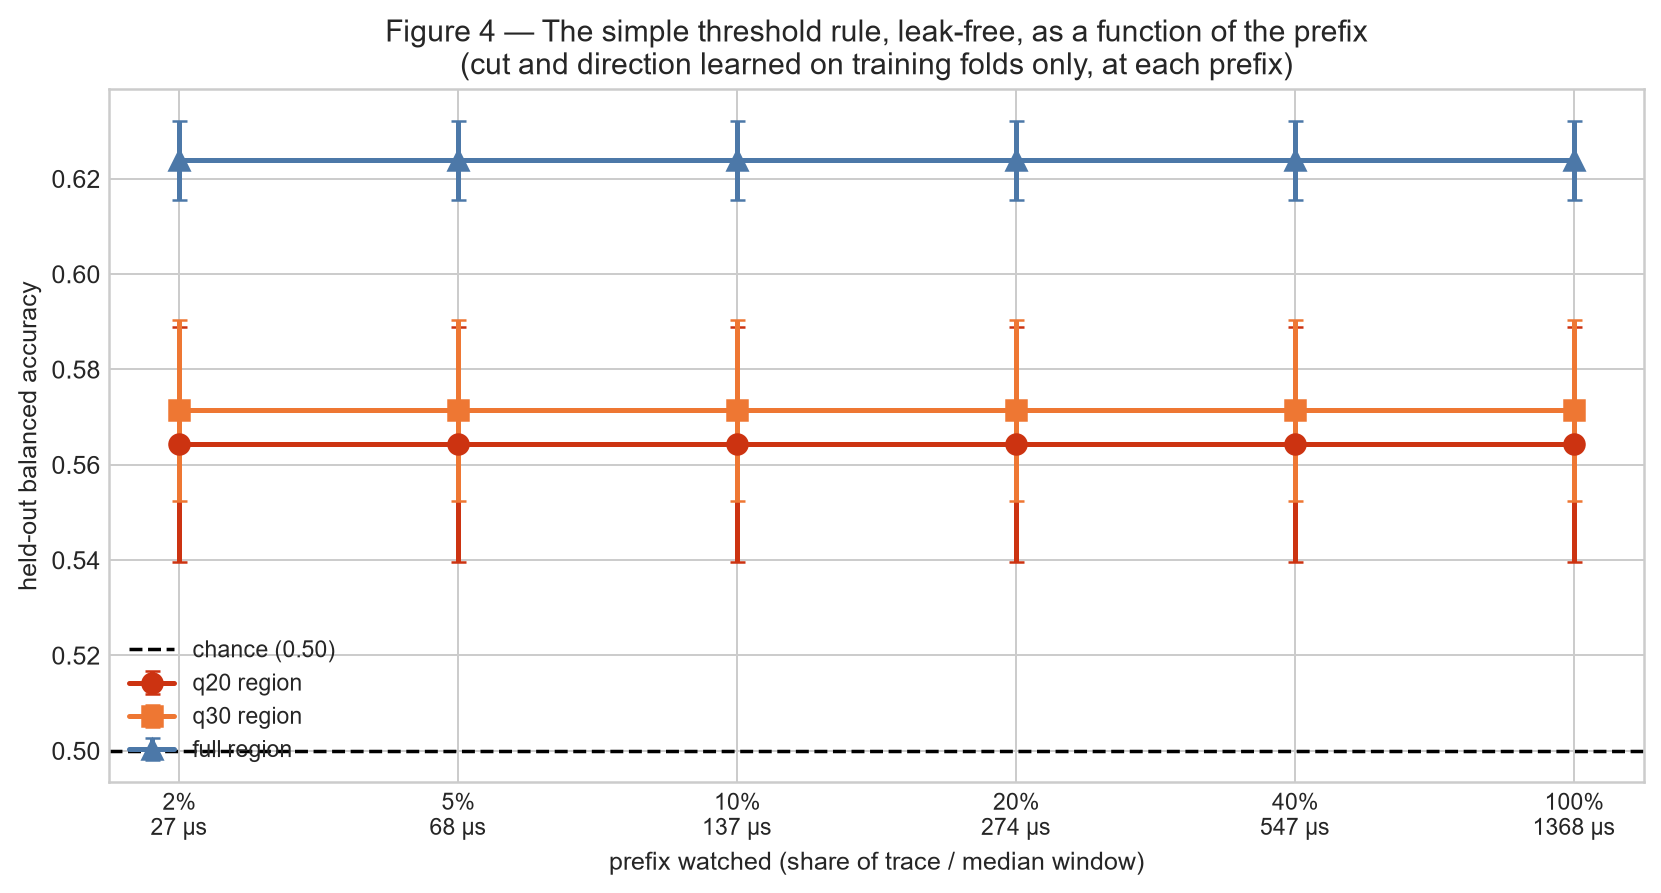

In [6]:
display(pd.read_csv(OUT/'prefix_threshold_summary.csv').round(4))
display(Image(filename=OUT/'figures'/'04_threshold_vs_prefix.png'))


## 6. The headline: gain over the 4D GPC versus how long we watch

Every model is the same ARD Matérn-3/2 GPC on the same folds. Only the observation window changes. Two of these models are shared with Phase 2.1R by construction — the 4D baseline and the 100% prefix — and the reproduction gate confirms they match the published numbers exactly, which is what lets us read this curve on the same scale.


reproduction rows: 54 | max abs difference: 1.1102230246251563e-16 | all PASS: True


metric,balanced_accuracy,keyhole_recall,pr_auc,roc_auc
model,,,,
gpc_4d,0.8739,0.8288,0.8769,0.9244
gpc_4d_plus_early_p02,0.8796,0.8454,0.8854,0.9283
gpc_4d_plus_early_p05,0.8824,0.8522,0.8922,0.9325
gpc_4d_plus_early_p10,0.8826,0.8537,0.8914,0.9325
gpc_4d_plus_early_p100,0.8830,0.8555,0.8914,0.9325
gpc_4d_plus_early_p20,0.8830,0.8555,0.8915,0.9326
gpc_4d_plus_early_p40,0.8830,0.8555,0.8914,0.9325


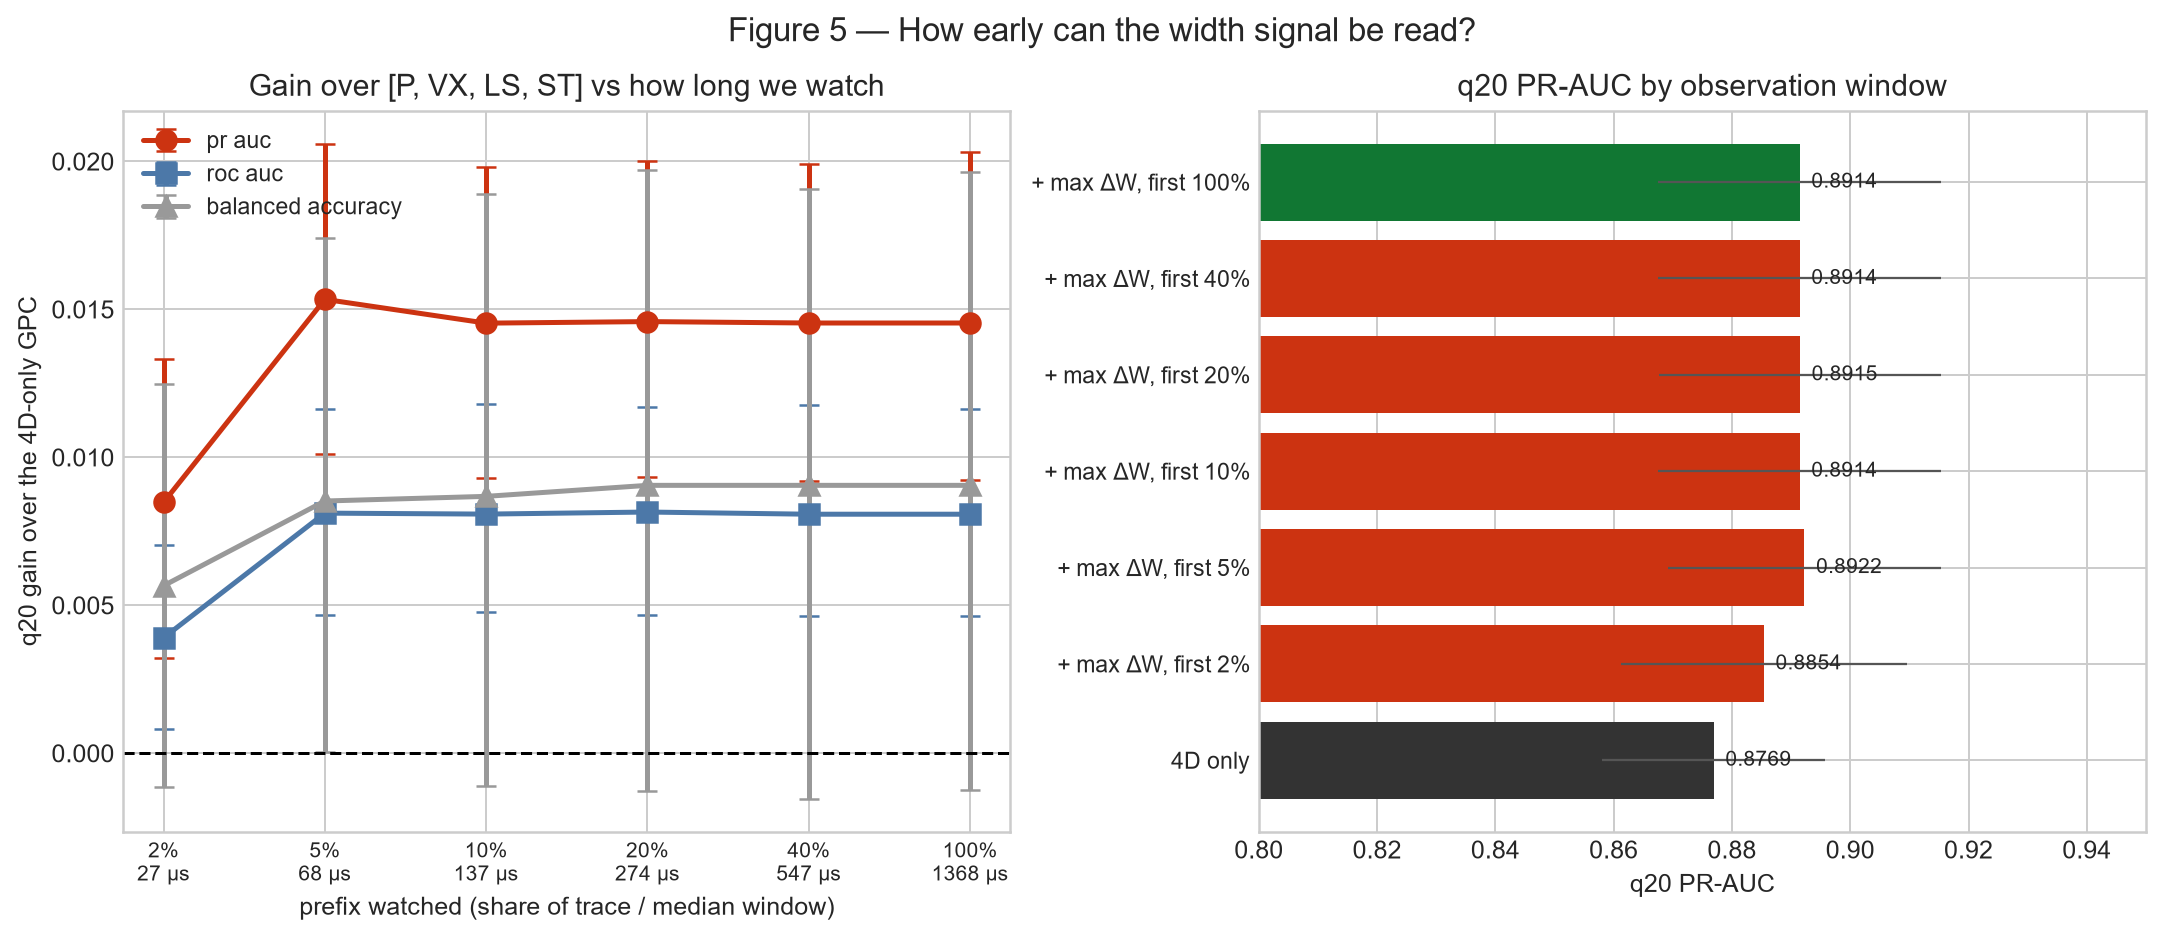

In [7]:
gate = pd.read_csv(OUT/'phase2_1r_reproduction_gate.csv')
print('reproduction rows:', len(gate), '| max abs difference:', gate.abs_difference.max(),
      '| all PASS:', bool(gate.status.eq('PASS').all()))
s = pd.read_csv(OUT/'model_oof_summary.csv')
display(s[(s.subset=='q20') & s.metric.isin(['balanced_accuracy','keyhole_recall','roc_auc','pr_auc'])].pivot(index='model', columns='metric', values='mean').round(4))
display(Image(filename=OUT/'figures'/'05_gpc_gain_vs_prefix.png'))


## 7. Does the rest of the trace add anything?

This is the question that matters, and a plain 'no significant difference' would not answer it — absence of evidence is not evidence of absence. So we use a **predeclared equivalence margin** of ±0.005 and ask whether the entire 95% interval for (whole trace − opening 5%) sits inside it. If it does, the rest of the trace demonstrably adds less than the margin.


,subset,metric,full_minus_early_prefix,ci_low,ci_high,equivalence_margin,interval_inside_margin,verdict
0,q20,balanced_accuracy,0.0005,-0.0030,0.0042,0.005,True,EQUIVALENT WITHIN MARGIN
1,q20,accuracy,0.0000,-0.0033,0.0033,0.005,True,EQUIVALENT WITHIN MARGIN
2,q20,keyhole_recall,0.0032,-0.0034,0.0099,0.005,False,INCONCLUSIVE
3,q20,roc_auc,-0.0000,-0.0005,0.0004,0.005,True,EQUIVALENT WITHIN MARGIN
4,q20,pr_auc,-0.0008,-0.0022,0.0003,0.005,True,EQUIVALENT WITHIN MARGIN
5,q20,brier_score,-0.0000,-0.0003,0.0002,0.005,True,EQUIVALENT WITHIN MARGIN
6,q30,balanced_accuracy,0.0004,-0.0020,0.0030,0.005,True,EQUIVALENT WITHIN MARGIN
7,q30,accuracy,-0.0000,-0.0023,0.0022,0.005,True,EQUIVALENT WITHIN MARGIN
8,q30,keyhole_recall,0.0014,-0.0027,0.0056,0.005,False,INCONCLUSIVE
9,q30,roc_auc,0.0000,-0.0003,0.0003,0.005,True,EQUIVALENT WITHIN MARGIN


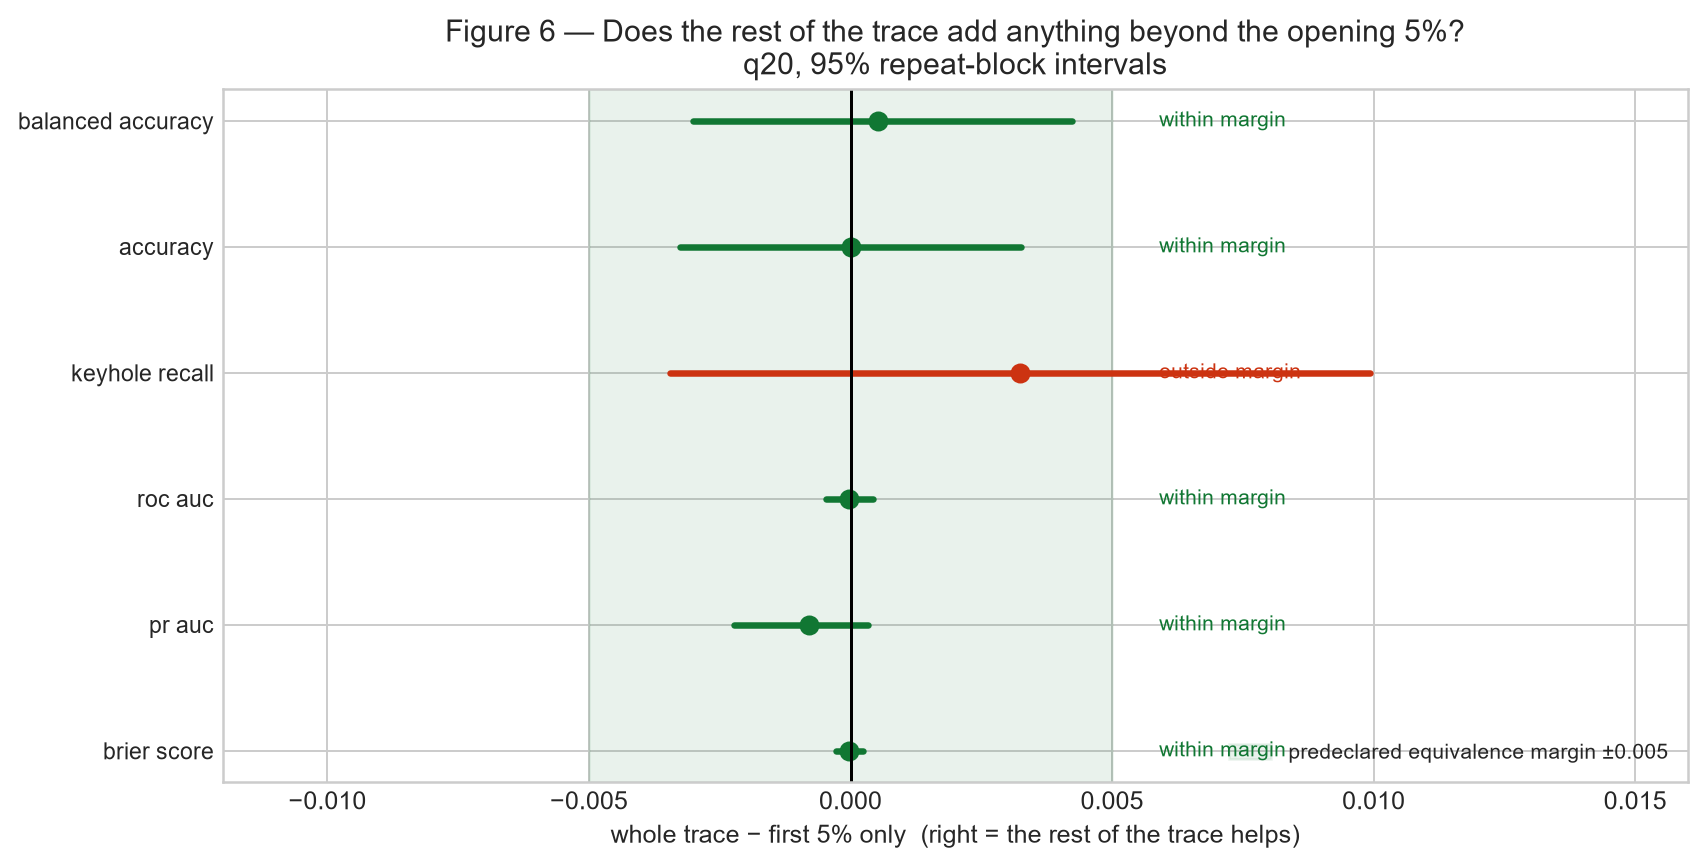

In [8]:
display(pd.read_csv(OUT/'early_vs_full_equivalence.csv').round(4))
display(Image(filename=OUT/'figures'/'06_early_vs_full_equivalence.png'))


## 8. What is supported, and what this is not

A retrospective prefix analysis of simulation traces is not an in-process monitoring result: no camera, no sensor noise, no latency budget, and the windows are tens of microseconds. Nothing here touches the acquisition rule.


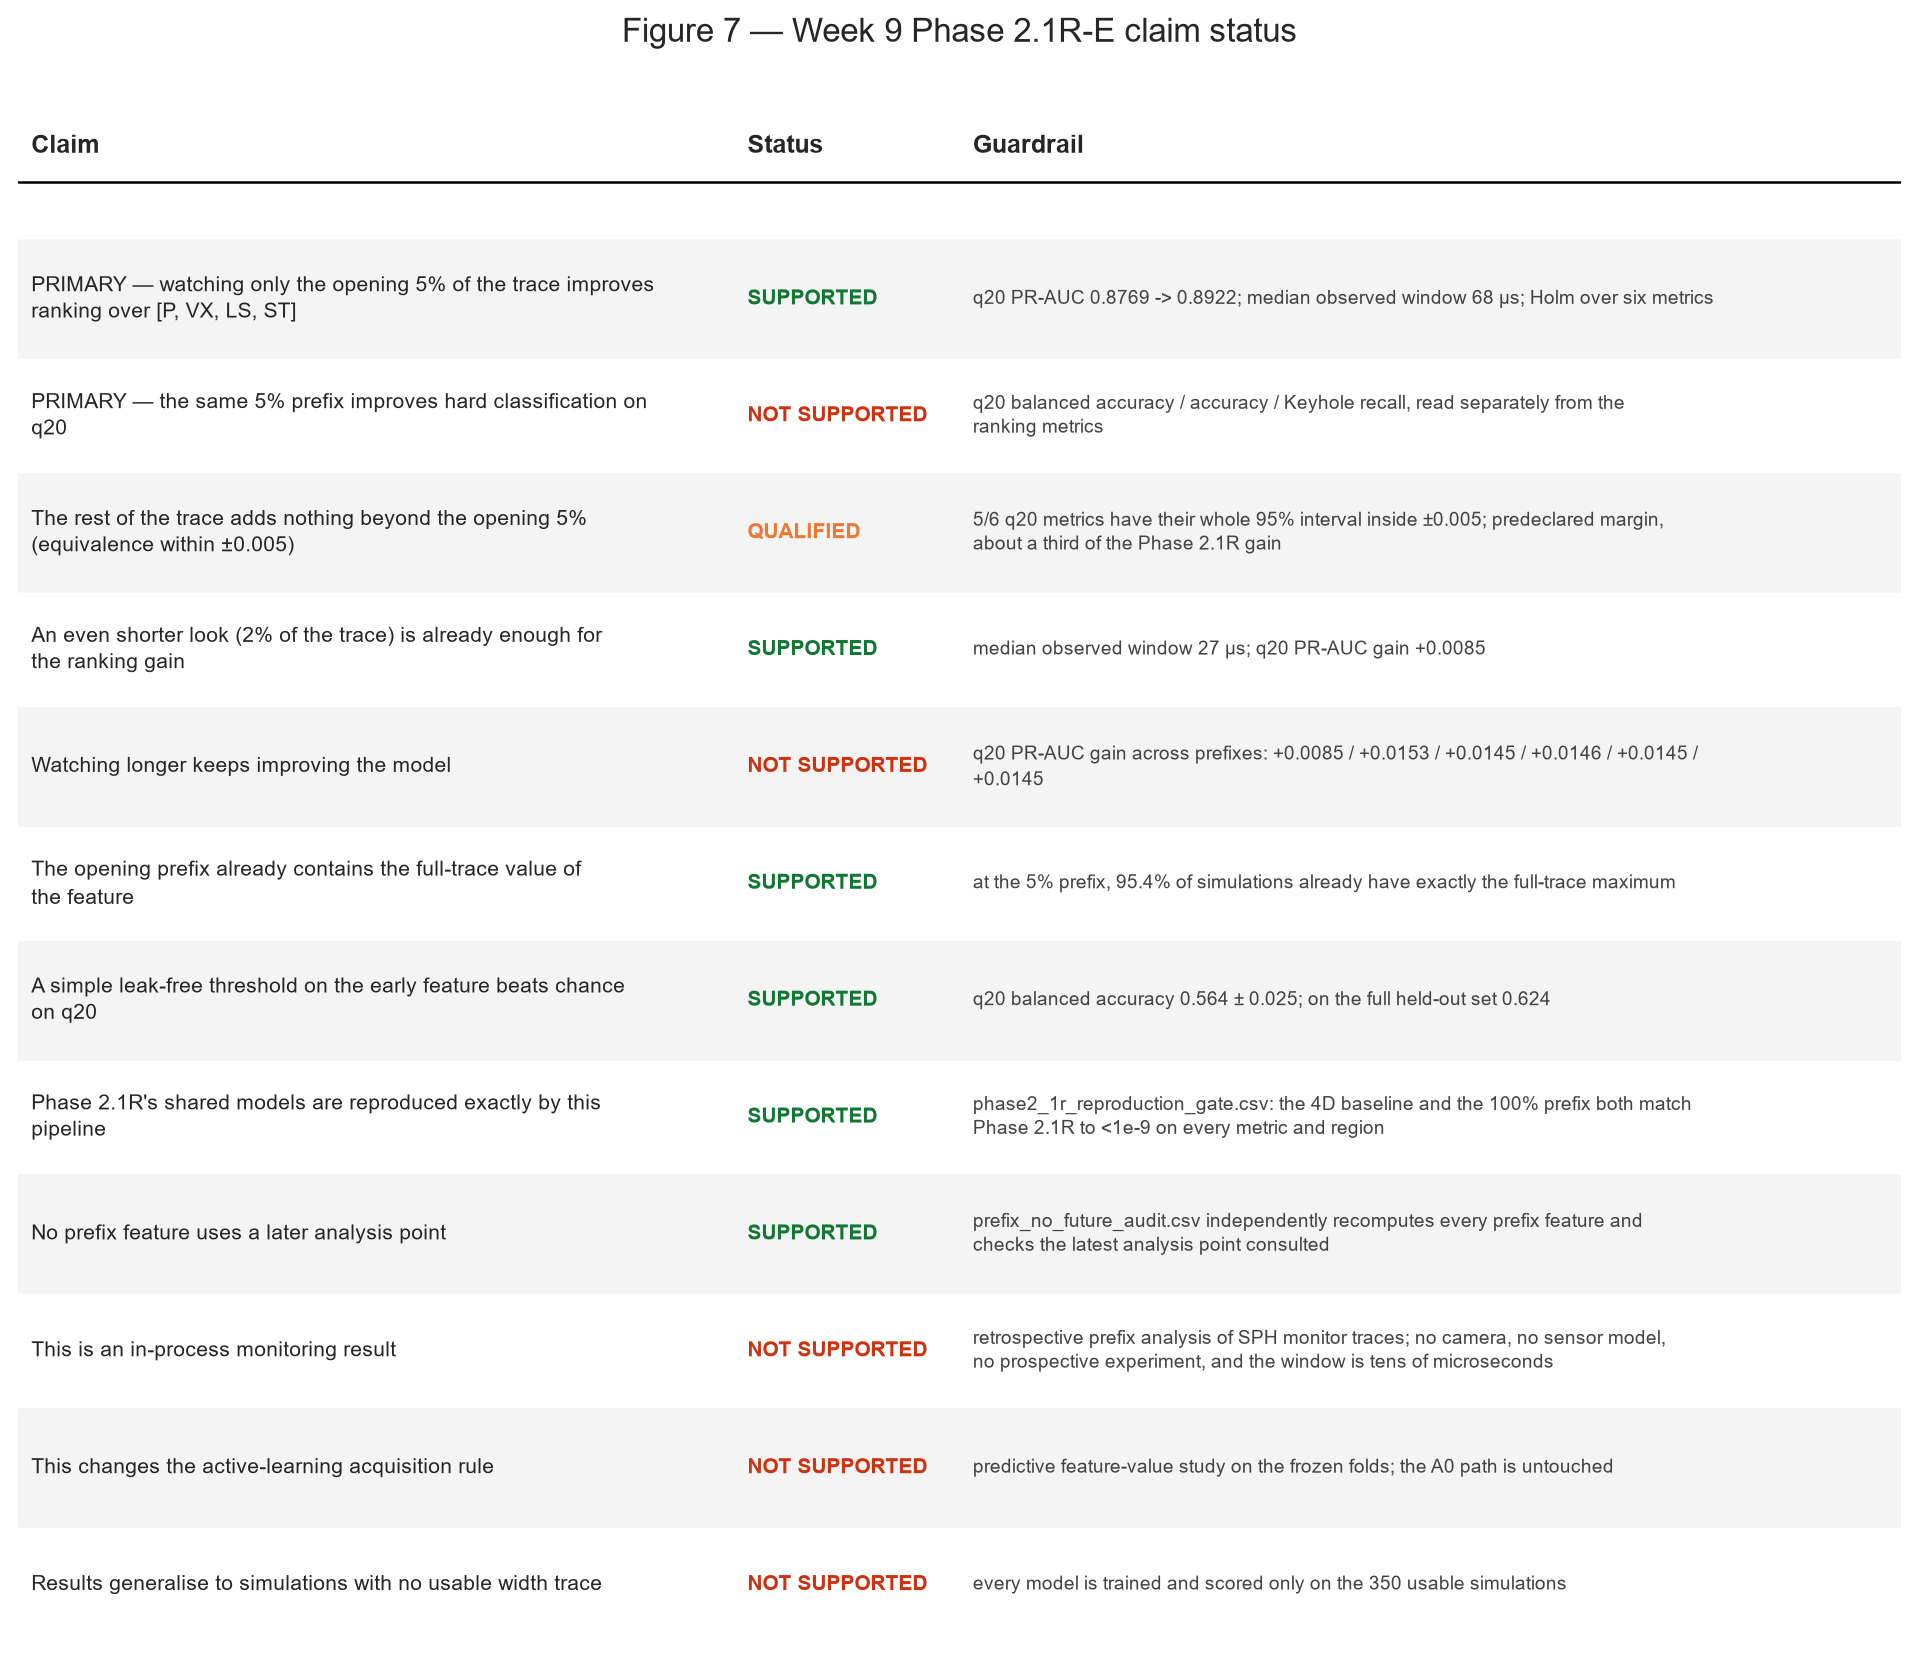

PASS


In [9]:
display(Image(filename=OUT/'figures'/'07_claim_status.png'))
print(json.loads((OUT/'validation_report.json').read_text(encoding='utf-8'))['status'])
